# Question 1: Classification - KNN vs Decision Tree
Dataset: UCI Spambase (`Data/spambase.csv`)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc
)

# 1. Load data
df = pd.read_csv('Data/spambase.csv')
print("Dataset shape:", df.shape)

# 2. Train-test split (80% train, 20% test)
X = df.drop('spam', axis=1)
y = df['spam']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (StandardScaler is required for KNN distance calculation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Dataset shape: (4601, 58)
Train size: 3680, Test size: 921


## a. K-Nearest Neighbour with Cross-Validation
Using 5-fold cross-validation on the training set to find the best $k$.

In [10]:
# 5-fold cross-validation to select k
k_values = [1, 3, 5, 7, 9, 11, 15]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k} with CV accuracy: {max(cv_scores):.4f}")

# Train final KNN with best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

Best k: 3 with CV accuracy: 0.9114


## b. Decision Tree Classifier
Training a Decision Tree with `max_depth=5` to prevent overfitting.

In [11]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Train Accuracy:", dt_model.score(X_train, y_train))
print("Decision Tree Test Accuracy: ", dt_model.score(X_test, y_test))

Decision Tree Train Accuracy: 0.9233695652173913
Decision Tree Test Accuracy:  0.8990228013029316


## Confusion Matrix
Comparing confusion matrices for both classifiers on the test set.

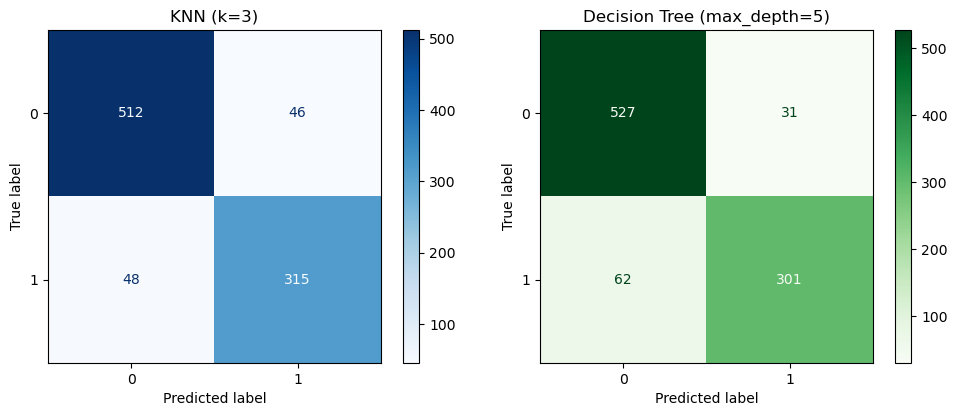

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax1, cmap='Blues')
ax1.set_title(f'KNN (k={best_k})')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax2, cmap='Greens')
ax2.set_title('Decision Tree (max_depth=5)')

plt.tight_layout()
plt.show()

## Metric Comparison
Comparing Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [13]:
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    f'KNN (k={best_k})': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn),
        roc_auc_score(y_test, y_prob_knn)
    ],
    'Decision Tree': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_prob_dt)
    ]
}

df_results = pd.DataFrame(results)
display(df_results.round(4))

,Metric,KNN (k=3),Decision Tree
0,Accuracy,0.8979,0.8990
1,Precision,0.8726,0.9066
2,Recall,0.8678,0.8292
3,F1-Score,0.8702,0.8662
4,ROC-AUC,0.9360,0.9271


## Overfitting and Model Complexity Analysis
Plotting training vs testing accuracy to see how model complexity affects performance:
- In KNN, smaller $k$ means higher complexity.
- In Decision Tree, larger `max_depth` means higher complexity.

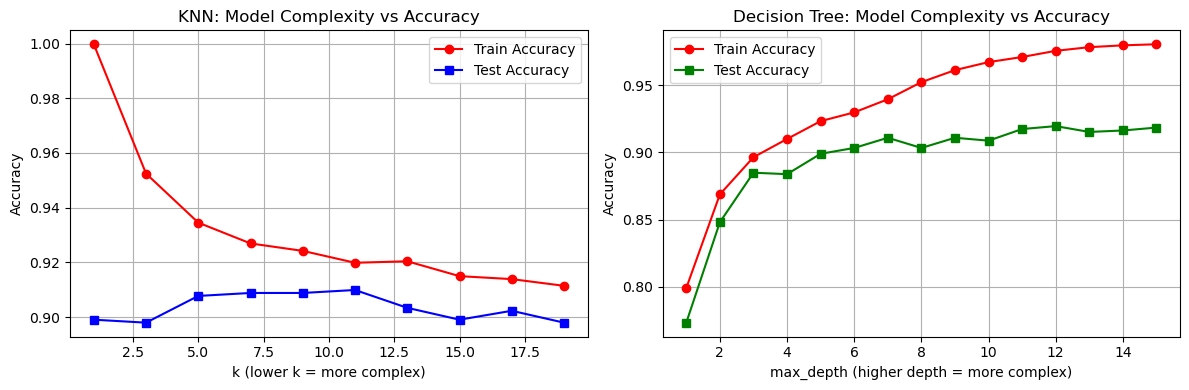

Unpruned Tree -> Train: 1.000, Test: 0.911 (Gap: 0.089)
Pruned Tree   -> Train: 0.923, Test: 0.899 (Gap: 0.024)


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. KNN complexity (vary k)
k_range = range(1, 20, 2)
knn_train, knn_test = [], []
for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_scaled, y_train)
    knn_train.append(clf.score(X_train_scaled, y_train))
    knn_test.append(clf.score(X_test_scaled, y_test))

ax1.plot(k_range, knn_train, label='Train Accuracy', color='red', marker='o')
ax1.plot(k_range, knn_test, label='Test Accuracy', color='blue', marker='s')
ax1.set_title('KNN: Model Complexity vs Accuracy')
ax1.set_xlabel('k (lower k = more complex)')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# 2. Decision Tree complexity (vary max_depth)
depth_range = range(1, 16)
dt_train, dt_test = [], []
for d in depth_range:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    dt_train.append(clf.score(X_train, y_train))
    dt_test.append(clf.score(X_test, y_test))

ax2.plot(depth_range, dt_train, label='Train Accuracy', color='red', marker='o')
ax2.plot(depth_range, dt_test, label='Test Accuracy', color='green', marker='s')
ax2.set_title('Decision Tree: Model Complexity vs Accuracy')
ax2.set_xlabel('max_depth (higher depth = more complex)')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Compare unpruned vs pruned tree
dt_unpruned = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Unpruned Tree -> Train: {dt_unpruned.score(X_train, y_train):.3f}, Test: {dt_unpruned.score(X_test, y_test):.3f} (Gap: {dt_unpruned.score(X_train, y_train) - dt_unpruned.score(X_test, y_test):.3f})")
print(f"Pruned Tree   -> Train: {dt_model.score(X_train, y_train):.3f}, Test: {dt_model.score(X_test, y_test):.3f} (Gap: {dt_model.score(X_train, y_train) - dt_model.score(X_test, y_test):.3f})")

**Observations on Overfitting & Complexity:**
- **KNN**: At $k=1$, the model overfits completely (training accuracy is ~100%, but test accuracy is lower). As $k$ increases, the model generalizes better until high $k$ starts underfitting.
- **Decision Tree**: An unpruned tree reaches ~100% training accuracy but only ~91% test accuracy (almost a 9% overfitting gap). Constraining `max_depth=5` keeps the model from memorizing noise and reduces the gap to ~2.4%.

## ROC Curve Analysis
Plotting ROC curves to compare the models across different thresholds.

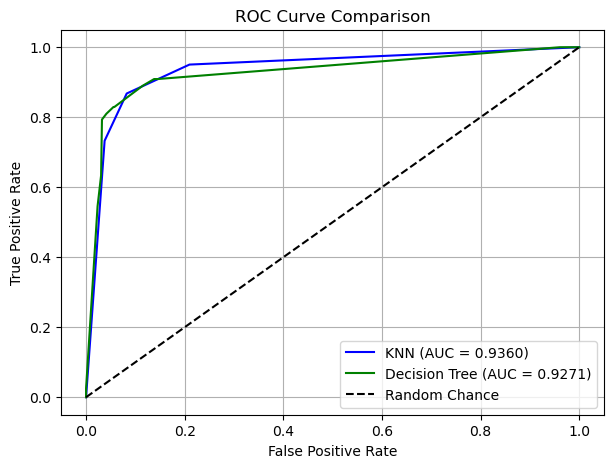

In [15]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.4f})', color='blue')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Conclusion: Which Classifier is Best?

Based on the ROC curve analysis, **K-Nearest Neighbour (KNN)** is the best classifier:
1. **Higher ROC-AUC**: KNN achieved an AUC of **0.9360**, which is higher than Decision Tree's **0.9271**.
2. **ROC Curve**: KNN's curve stays above the Decision Tree curve across low false positive rates, meaning it catches more spam with fewer false alarms.